# 04 · Relaciones, ajuste e interpretación

**CE1.4, CE2.1–2.4.** Correlación Pearson/Spearman, regresión simple/múltiple, diagnóstico y límites causales. Dos sesiones según necesidades.

**Caso:** ComercioSur, datos simulados. Ejecutar en orden con kernel activo. Cada ejercicio exige una interpretación y un límite; consultar [manual](../material_propio/EBA_manual_cientifico.html) y [guía](../guia_maestra_eba.html). El curso presupone manejo elemental de tablas de Fundamentos. No instalar paquetes desde las celdas.

### Antes de ejecutar

Núcleo · 90–120 min orientativos.

**Objetivo:** Interpretar coeficientes condicionados y evaluar diagnósticos del modelo.

**Preparación:** Dispersión, correlación e intervalos; unidad de cada variable.

**Ejemplo de referencia:** Modelar tiempo con ticket, canal y campaña y examinar residuos y errores HC3.

**Práctica:** Comparar ajuste simple y múltiple y explicar por qué un coeficiente cambia.

**Criterio de logro:** Justificar especificación, interpretar un coeficiente y señalar un límite causal.

[Guía y secuencia](../guia_maestra_eba.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/EBA_manual_cientifico.html#sec-regresion)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, Markdown
RAIZ=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'_transversal/datos').is_dir())
sys.path.insert(0,str(RAIZ/'02_Estadistica_Business_Analytics/reproducibilidad'))
from eba_recursos import *
df=pedidos()
plt.rcParams.update({'figure.figsize':(7,3.4),'axes.spines.top':False,'axes.spines.right':False})


<a id="correlacion"></a>
## Asociación observacional

Ticket y tiempo comparten diferencias de canal. Pearson evalúa asociación lineal; Spearman asociación monótona por rangos. No se interpreta correlación como causalidad. Examine siempre dispersión y composición.

Pearson    -0.006815
Spearman   -0.023565
dtype: float64

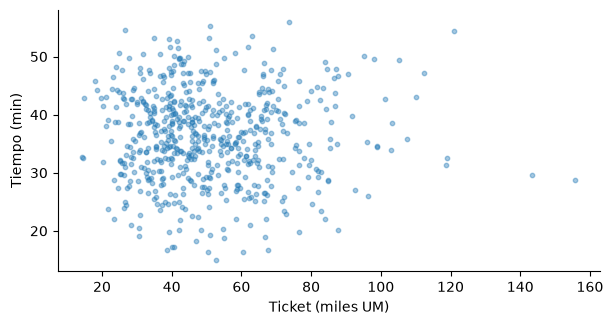

In [2]:
display(pd.Series({'Pearson':stats.pearsonr(df.ticket_mil,df.tiempo_min).statistic,'Spearman':stats.spearmanr(df.ticket_mil,df.tiempo_min).statistic}));plt.scatter(df.ticket_mil,df.tiempo_min,s=10,alpha=.4);plt.xlabel('Ticket (miles UM)');plt.ylabel('Tiempo (min)');plt.show()

<a id="regresion"></a>
## MCO simple y múltiple

Modelo simple tiempo~ticket; modelo múltiple agrega canal y campañas. Las categorías de referencia son Tienda y A. Los coeficientes de B/C comparan campañas manteniendo ticket y canal constantes. Reportar unidades y población; no interpretar el intercepto fuera del rango observado.

In [3]:
import statsmodels.formula.api as smf
simple=smf.ols('tiempo_min ~ ticket_mil',data=df).fit()
modelo=smf.ols('tiempo_min ~ ticket_mil + C(canal) + C(campana)',data=df).fit()
robusto=modelo.get_robustcov_results(cov_type='HC3')
display(pd.DataFrame({'beta':robusto.params,'SE_HC3':robusto.bse,'p':robusto.pvalues,'li':robusto.conf_int()[:,0],'ls':robusto.conf_int()[:,1]},index=modelo.params.index));print('R² simple/múltiple:',simple.rsquared,modelo.rsquared)

,beta,SE_HC3,p,li,ls
Intercept,36.634746,1.038599,6.175123e-148,34.594980,38.674512
C(canal)[T.Web],3.594752,0.616157,8.882235e-09,2.384646,4.804859
C(campana)[T.B],-3.952494,0.683107,1.165708e-08,-5.294088,-2.610900
C(campana)[T.C],-8.032247,0.699751,1.088570e-27,-9.406529,-6.657965
ticket_mil,0.022394,0.015036,1.369197e-01,-0.007136,0.051923


R² simple/múltiple: 4.644867194580904e-05 0.22133317428007182


<a id="diagnostico"></a>
## Residuos y supuestos

Linealidad en parámetros, observaciones independientes, especificación del promedio y ausencia de colinealidad perfecta. Homocedasticidad y normalidad son supuestos adicionales de intervalos clásicos exactos. HC3 atiende heterocedasticidad de coeficientes; no soluciona confusión, dependencia ni mala especificación.

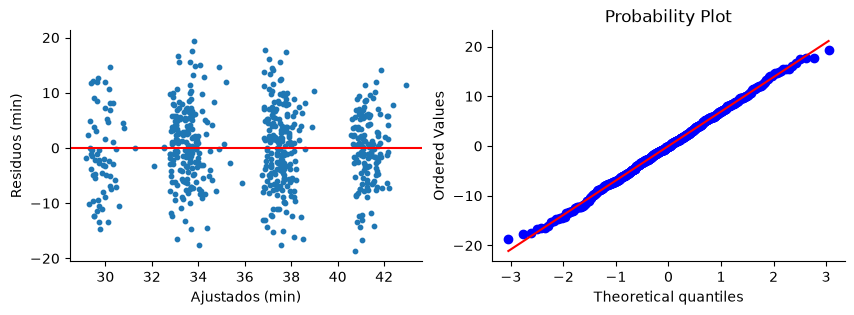

RMSE de ajuste: 6.902149597574263


In [4]:
fig,ax=plt.subplots(1,2,figsize=(10,3));ax[0].scatter(modelo.fittedvalues,modelo.resid,s=10);ax[0].axhline(0,color='red');ax[0].set(xlabel='Ajustados (min)',ylabel='Residuos (min)');stats.probplot(modelo.resid,plot=ax[1]);plt.show();print('RMSE de ajuste:',np.sqrt(np.mean(modelo.resid**2)))

<a id="prediccion"></a>
## Media condicional frente a observación nueva

Estos intervalos clásicos se calculan con el modelo homocedástico. El intervalo individual incorpora variación residual; el de la media, incertidumbre del promedio condicional. No equivalen a desempeño fuera de muestra ni respaldan extrapolación.

In [5]:
@widgets.interact(ticket=widgets.FloatSlider(value=50,min=20,max=100,step=5),campana=widgets.Dropdown(options=['A','B','C']))
def escenario(ticket,campana):
    nuevo=pd.DataFrame({'ticket_mil':[ticket],'canal':['Web'],'campana':[campana]});display(modelo.get_prediction(nuevo).summary_frame(alpha=.05));print('Intervalos clásicos: requieren especificación y varianza residual adecuadas.')

interactive(children=(FloatSlider(value=50.0, description='ticket', min=20.0, step=5.0), Dropdown(description=…

<a id="causalidad"></a>
## Actividad: explicación ejecutiva

Escriba 80 palabras sobre campaña C y 80 sobre canal. Explique por qué el mecanismo aleatorio apoya la primera comparación causal y no la segunda. Una asociación ajustada sigue dependiendo de supuestos. Compruebe MCO con álgebra independiente.

In [6]:
X=modelo.model.exog;y=modelo.model.endog;beta=np.linalg.lstsq(X,y,rcond=None)[0];assert np.allclose(beta,modelo.params);print('Coeficientes MCO comprobados con mínimos cuadrados NumPy.');display(df.groupby(['canal','campana']).agg(n=('id','size'),tiempo=('tiempo_min','mean')))

Coeficientes MCO comprobados con mínimos cuadrados NumPy.


n     tiempo
canal  campana                
Tienda A         70  38.386714
       B         80  34.439750
       C         67  28.731493
Web    A        139  41.009712
       B        129  37.069535
       C        115  33.949478

## Comprobación y entrega

Responda la autoevaluación y complete la actividad del último bloque. Entregue objetivo, método, supuesto, resultado con unidades y decisión condicionada. Las soluciones orientadoras permiten estudiar, pero no sustituyen su interpretación.

In [7]:
auto_04=pregunta('¿Un R² alto prueba causalidad o buen pronóstico futuro?','Sí, demuestra ambos','No, son propiedades diferentes','R² resume ajuste; causalidad requiere diseño y predicción requiere evaluación fuera de muestra.')
display(auto_04)